# Rapport analytique - catalogue alimentaire francais (Open Food Facts)

Base `off_projet` sur MongoDB Atlas. Quatre questions metier, quatre agregations, quatre visualisations.

| # | Question | Mecanisme |
|---|---|---|
| Q1 | Le sucre suit-il vraiment le Nutri-Score ? | `$group` par grade |
| Q2 | Quelles familles de produits sont les plus ultra-transformees (NOVA 4) ? | `$group` + ratio conditionnel |
| Q3 | Quels additifs sont les plus repandus ? | `$unwind` + `$group` + `$lookup` referentiel |
| Q4 | Comment le catalogue evolue-t-il dans le temps ? | `$group` par annee de creation |


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import pandas as pd
import matplotlib.pyplot as plt
from src.db import get_db, target
from src import aggregations as agg

db = get_db()
print('cible :', target(), '| base :', db.name)
print('produits   :', db.products.count_documents({}))
print('categories :', db.categories.count_documents({}))
print('additives  :', db.additives.count_documents({}))

cible : ATLAS | base : off_projet
produits   : 18417
categories : 5314


additives  : 266


## Q1 - Sucre moyen par Nutri-Score
Hypothese : le sucre pour 100 g augmente vers les mauvais grades. On regarde ou elle tient et ou elle ne tient pas.

,nutriscore,sucre_moyen_100g,sel_moyen_100g,n
0,a,2.884450,0.323702,2374
1,b,2.347718,0.349895,2657
2,c,6.203297,0.610085,3611
3,d,37.533904,0.856007,3450
4,e,28.244121,1.262243,3049


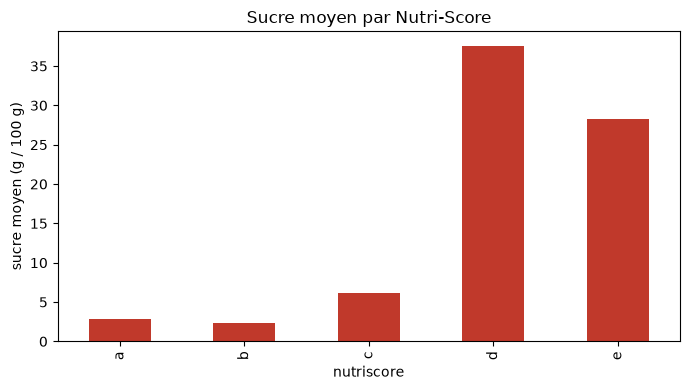

In [2]:
q1 = pd.DataFrame(agg.sucre_par_nutriscore()).rename(columns={'_id': 'nutriscore'})
display(q1)
ax = q1.plot(x='nutriscore', y='sucre_moyen_100g', kind='bar', legend=False,
             color='#c0392b', figsize=(7, 4))
ax.set_ylabel('sucre moyen (g / 100 g)'); ax.set_title('Sucre moyen par Nutri-Score')
plt.tight_layout(); plt.savefig('q1_sucre_nutriscore.png', dpi=110); plt.show()

## Q2 - Part de produits ultra-transformes (NOVA 4) par categorie feuille

,categorie,n,part_nova4
0,stacked-extruded-potato-crisps,73,100.0
1,fr:brioches-tranchees,56,98.2
2,sliced-breads,45,97.8
3,fr:charcuteries-cuites,118,97.5
4,viennoiseries,492,96.3
5,sweet-spreads,429,95.6
6,wholemeal-sliced-breads,42,95.2
7,ice-creams-and-sorbets,94,94.7
8,soft-drinks,115,93.0
9,sweetened-beverages,381,92.9


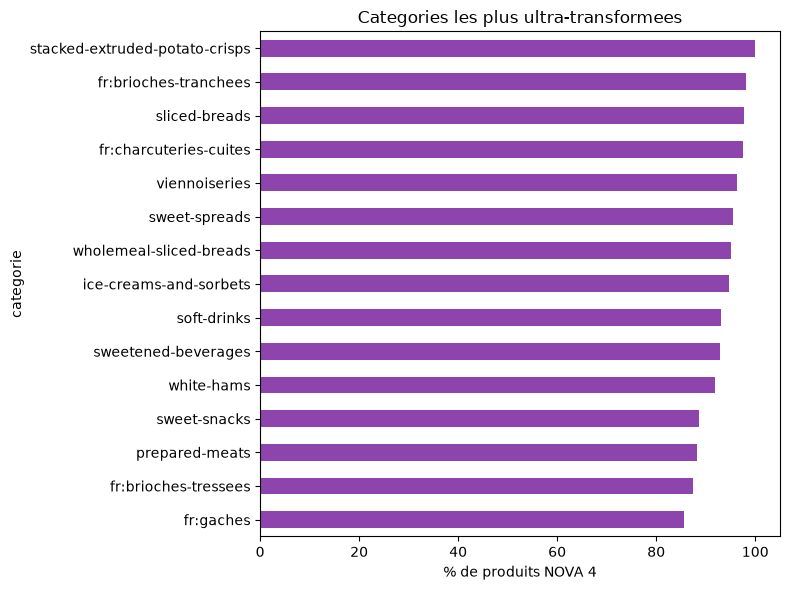

In [3]:
q2 = pd.DataFrame(agg.part_ultra_transforme_par_categorie()).rename(columns={'_id': 'categorie'})
q2['categorie'] = q2['categorie'].str.replace('en:', '', regex=False)
display(q2)
ax = q2.sort_values('part_nova4').plot(x='categorie', y='part_nova4', kind='barh',
                                       legend=False, color='#8e44ad', figsize=(8, 6))
ax.set_xlabel('% de produits NOVA 4'); ax.set_title('Categories les plus ultra-transformees')
plt.tight_layout(); plt.savefig('q2_nova4_categories.png', dpi=110); plt.show()

## Q3 - Additifs les plus frequents (avec `$lookup` sur le referentiel `additives`)

,tag,n_produits,code
0,en:e330,2152,E330
1,en:e322,1652,E322
2,en:e322i,1168,E322I
3,en:e471,1050,E471
4,en:e300,1036,E300
5,en:e500,1011,E500
6,en:e14xx,929,E14XX
7,en:e440,747,E440
8,en:e415,671,E415
9,en:e412,476,E412


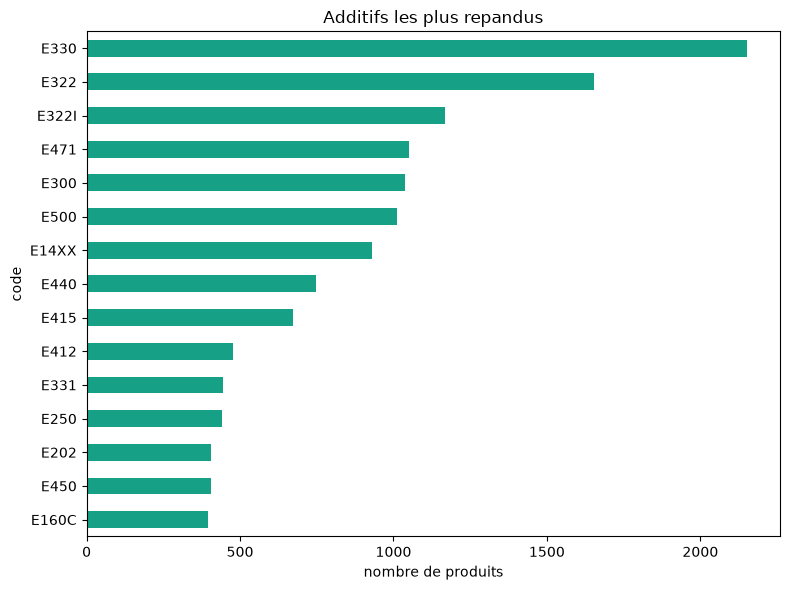

In [4]:
q3 = pd.DataFrame(agg.additifs_les_plus_frequents()).rename(columns={'_id': 'tag'})
display(q3)
ax = q3.sort_values('n_produits').plot(x='code', y='n_produits', kind='barh',
                                       legend=False, color='#16a085', figsize=(8, 6))
ax.set_xlabel('nombre de produits'); ax.set_title('Additifs les plus repandus')
plt.tight_layout(); plt.savefig('q3_additifs.png', dpi=110); plt.show()

## Q4 - Evolution du catalogue par annee de creation

,n_ajouts,nutriscore_moyen,annee
0,475,2.98,2012
1,1119,2.99,2013
2,1010,3.04,2014
3,1833,3.08,2015
4,2024,3.16,2016
5,2493,3.21,2017
6,1979,3.06,2018
7,1120,3.13,2019
8,1048,3.06,2020
9,1109,3.03,2021


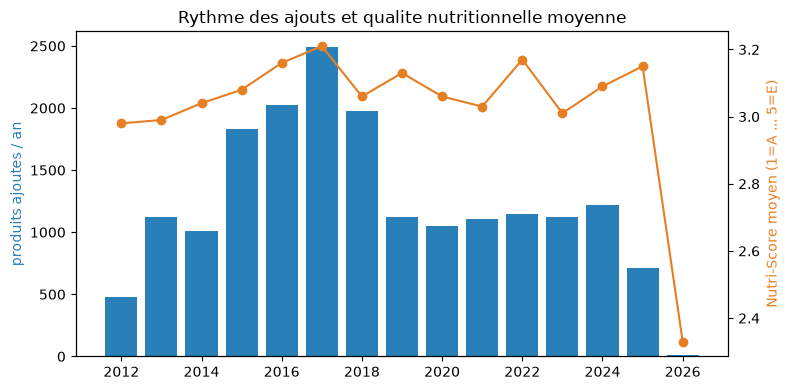

In [5]:
q4 = pd.DataFrame(agg.ajouts_par_annee())
q4 = q4[q4['annee'] >= 2012]
display(q4)
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.bar(q4['annee'], q4['n_ajouts'], color='#2980b9', label='produits ajoutes')
ax1.set_ylabel('produits ajoutes / an', color='#2980b9')
ax2 = ax1.twinx()
ax2.plot(q4['annee'], q4['nutriscore_moyen'], color='#e67e22', marker='o', label='Nutri-Score moyen')
ax2.set_ylabel('Nutri-Score moyen (1=A ... 5=E)', color='#e67e22')
ax1.set_title('Rythme des ajouts et qualite nutritionnelle moyenne')
plt.tight_layout(); plt.savefig('q4_evolution.png', dpi=110); plt.show()

## Lecture

- **Q1** : la relation sucre / Nutri-Score n'est pas monotone. A, B et C restent bas (2 a 6 g / 100 g). Le sucre bondit en D (~37 g) puis **redescend en E** (~28 g) : le grade E rassemble beaucoup de produits tres sales ou edulcores (le sel moyen y est le plus eleve, ~1,3 g), pas seulement des produits sucres. Le **sel**, lui, croit regulierement de A vers E. Autrement dit : le sucre marque surtout le passage vers D, le sel discrimine sur toute l'echelle.

- **Q2** : chips extrudees, brioches tranchees, pain de mie, charcuterie cuite, viennoiseries : 95 a 100 % de NOVA 4. Les categories brutes (fruits, legumes, eaux plates) sont a l'oppose.

- **Q3** : les additifs de tete sont des acidifiants / correcteurs d'acidite et emulsifiants (E330 acide citrique, E322 lecithines, E471) : omnipresents, peu polemiques. Le `$lookup` sur le referentiel `additives` fournit le code E lisible.

- **Q4** : la contribution communautaire culmine vers 2016-2018 puis reflue ; le Nutri-Score moyen reste stable (~3,1), ce qui indique que l'elargissement de la couverture n'introduit pas de biais de qualite.

Limites : echantillon francais issu de l'API OFF (pas le dump mondial) ; `nova_group` et `nutriscore_grade` manquants sur une partie des produits, exclus des moyennes correspondantes ; un produit vendu dans plusieurs pays compte une fois (filtre France).
